# Estimating Fourth-Down Conversion Success for Strategic Play-Calling

**Sahil Sangani** 

---
embed-resources: true
echo: false
---

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import os

## Introduction

Decision making on fourth down represents one of the most critical and high-leverage moments in American football. Unlike earlier downs, where the offense has multiple opportunities to advance the ball, a fourth down situation typically marks the final chance to gain the remaining yards needed to continue the drive. Failure to convert results in a turnover on downs, immediately giving possession to the opposing team, often with favorable field position. As a result, fourth down decisions involve a clear tradeoff between risk and reward.

Traditionally, teams have relied on conservative heuristics when facing fourth down, frequently choosing to punt the ball away or attempt a field goal rather than keeping the offense on the field. However, advances in sports analytics have shown that these choices are not always optimal. The potential reward of a successful fourth down conversion—maintaining possession, improving field position, and increasing scoring opportunities—can outweigh the risk of failure in many game situations. The challenge lies in accurately quantifying the likelihood of success given the specific context of the play.

A fourth down conversion attempt is influenced by several factors, including the number of yards needed for a first down, the offense’s field position relative to the opponent’s end zone, and the type of play called, such as a run or a pass. These variables interact in complex ways, making intuitive decision making difficult. As a result, probabilistic models that estimate the chance of conversion provide a valuable tool for understanding when aggressive play-calling may be justified.

In this project, we develop a model that estimates the probability of successfully converting a fourth down attempt using play-by-play data from the NFL. By focusing exclusively on situations where teams choose to go for it, the model isolates the outcome of the decision rather than the decision itself. This conversion probability can then be used as a modular input to a larger decision-making system, enabling offensive coordinators to evaluate play-calling strategies and their downstream impact on the probability of winning the game.

## Data

In [2]:
football = pd.read_parquet(
    "https://lab.cs307.org/football/data/football.parquet",
)

In [3]:
football

,game_date,togo,yardline,converted,play_type,posteam,defteam
0,2019-09-08,5.0,20.0,Yes,Pass,ATL,MIN
1,2019-09-08,2.0,23.0,Yes,Pass,ATL,MIN
2,2019-09-08,1.0,70.0,Yes,Run,BAL,MIA
3,2019-09-08,3.0,3.0,Yes,Pass,BAL,MIA
4,2019-09-08,1.0,36.0,No,Run,BUF,NYJ
...,...,...,...,...,...,...,...
4548,2025-01-26,6.0,66.0,Yes,Pass,WAS,PHI
4549,2025-01-26,11.0,60.0,No,Pass,WAS,PHI
4550,2025-01-26,3.0,63.0,No,Run,WAS,PHI
4551,2025-02-09,4.0,53.0,No,Pass,KC,PHI


Response:

**`converted`** 

- `[object]` result of fourth-down conversion attempt. One of No or Yes.

Features: 

**`togo`**

- `[float64]` distance in yards from either the first down marker or the end zone in goal down situations. Distance needed to successfully convert the fourth-down attempt.

**`yardline`**

- `[float64]` distance in yards from the opponent’s end zone. Distance needed to score a touchdown.

**`play_type`**

- `[object]` type of play. One of `Pass` or `Run`. Pass plays include sacks. Run plays include scrambles. 

**`posteam`**

- `[object]` the abbreviation for the team with possession of the ball.

**`defteam`**

- `[object]` the abbreviation for the team on defense.

In [4]:
#| include: false
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device!")

Using mps device!


Splitting data in train and test based on game date. I want to use about 20% of the data for testing to have reliable results and I want the test set to reflect most recent teams. So I am choosing to use 2024-2025 football season for test dataset and 2019-2024 football seasons as training data.

In [5]:
df_train = football[football['game_date'] < '2024-04-01']
df_test = football[football['game_date'] > '2024-04-01']
print(f"test data size: {(df_test.shape[0] / football.shape[0]) * 100:.0f}% ")

test data size: 18% 


The train test split was made using April 2024 as cutoff for train and test data, where fourth down instances in games before April 2024 were used as training data and instances in games during or after April 2024 were used as test data. I chose April 2024 because there are no NFL games going on during the month of April and this split allowed me to leave our 2024-2025 season as test data which is about 18% of my entire data.

@fig-target_balance shows what proportion of fourth down attempts were successful in the training data.

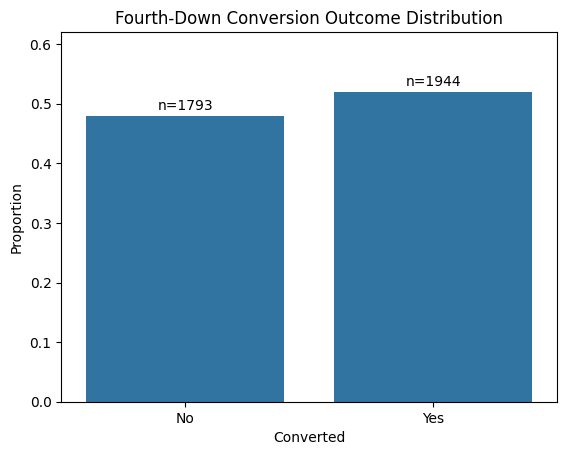

In [6]:
#| echo: false
#| label: fig-target_balance
#| fig-cap: "Proportion of successful fourth down conversions."
count = df_train["converted"].value_counts().sort_index()
prop = df_train["converted"].value_counts(normalize=True).sort_index()

ax = sns.barplot(prop)
for i, v in enumerate(prop.values):
    ax.text(
        i, 
        v + 0.01,                
        f'n={count.iloc[i]}',   
        ha='center',
        fontsize=10
    )


plt.title('Fourth-Down Conversion Outcome Distribution')
plt.ylabel('Proportion')
plt.xlabel('Converted')
plt.ylim(0, prop.max() + 0.1)
plt.show()

Missing values in training data: 

In [7]:
df_train.isna().sum()

game_date    0
togo         0
yardline     0
converted    0
play_type    0
posteam      0
defteam      0
dtype: int64

Missing values in test data:


In [8]:
df_test.isna().sum()

game_date    0
togo         0
yardline     0
converted    0
play_type    0
posteam      0
defteam      0
dtype: int64

In [9]:
features = ['togo','yardline','play_type','posteam','defteam']
X_train = df_train[features]
y_train = df_train['converted']
y_train = y_train.map({'Yes': 1, 'No': 0})

X_test = df_test[features]
y_test = df_test['converted']
y_test = y_test.map({'Yes': 1, 'No': 0})

## Modeling

I want to build a logistic regression model because we are interested in the probability of a successful fourth down conversion and logistic regression models are usually well calibrated.

In [64]:
# train model on all features
numeric_features = ["togo", "yardline"]
binary_features = ["play_type"]
team_features = ["posteam", "defteam"]

# define preprocessing
numeric_transformer = Pipeline(
    [
        ("scalar", StandardScaler())
    ]
)

team_transformer = Pipeline(
    [
        ("targetencoder", TargetEncoder()),
    ]
)

binary_transformer = Pipeline(
    [
        ("encoder", OneHotEncoder(drop='first'))
    ]
)

column_transformer = ColumnTransformer(
    [
        ("numeric", numeric_transformer, numeric_features),
        ("team", team_transformer, team_features),
        ("binary", binary_transformer, binary_features)
    ]
)

In [65]:
logreg = Pipeline(
    [
        ("preprocessor", column_transformer),
        ("classifier", LogisticRegression())
    ]
)

In [66]:
logreg.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('team', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]


In [68]:
print(f"accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred):.4f}")
print(f"f1 score: {f1_score(y_true=y_test, y_pred=y_pred):.4f}")
print(f"roc-auc score: {roc_auc_score(y_true=y_test, y_score=y_prob):.4f}")
print(f"brier score: {brier_score_loss(y_true=y_test, y_proba=y_prob):.4f}")

accuracy: 0.6483
f1 score: 0.7062
roc-auc score: 0.6860
brier score: 0.2185


Now that we have a baseline score, I want to build a tree based model to try getting a better score. In future I would also like to build a neural network using pytorch for a better score.

In [69]:
model = Pipeline(
    [
        ("preprocessor", column_transformer),
        ("classifier", RandomForestClassifier(random_state=27))
    ]
)

param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',  
    cv=5,
    n_jobs=-2,
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=27))])
,param_grid,"{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('team', ...), ...]"


In [70]:
grid_search.best_params_

{'classifier__max_depth': 5,
 'classifier__max_features': 'log2',
 'classifier__min_samples_leaf': 5,
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 500}

In [71]:
y_pred = grid_search.predict(X_test)
y_prob = grid_search.predict_proba(X_test)[:, 1]
print(f"accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred):.4f}")
print(f"f1 score: {f1_score(y_true=y_test, y_pred=y_pred):.4f}")
print(f"roc-auc score: {roc_auc_score(y_true=y_test, y_score=y_prob):.4f}")
print(f"brier score: {brier_score_loss(y_true=y_test, y_proba=y_prob):.4f}")

accuracy: 0.6446
f1 score: 0.6934
roc-auc score: 0.6903
brier score: 0.2194


We got almost similar, slightly worse, scores for random forest model and logistic regression model. So I am choosing to use logistic regression model as the best model.

Neural Network 

In [72]:
# train model on all features
numeric_features = ["togo", "yardline"]
binary_features = ["play_type"]
team_features = ["posteam", "defteam"]

team_transformer = Pipeline(
    [
        ("targetencoder", TargetEncoder()),
    ]
)

binary_transformer = Pipeline(
    [
        ("onehot", OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore"))
    ]
)

column_transformer = ColumnTransformer(
    [
        ("numeric", "passthrough", numeric_features),
        ("team", team_transformer, team_features),
        ("binary", binary_transformer, binary_features)
    ],
    remainder="drop"
)

In [73]:
X_train_enc = column_transformer.fit_transform(X_train, y_train)
X_test_enc = column_transformer.transform(X_test)

Team identifiers were target encoded using scikit-learn’s TargetEncoder, which replaces each team with its historical fourth-down conversion rate computed from the training data only. While this approach captures team-level tendencies, it does not explicitly regularize rare categories, which may introduce noise for teams with fewer observations.

In [74]:
feature_names = (
    numeric_features +
    team_features +
    list(
        column_transformer
        .named_transformers_["binary"]
        .named_steps["onehot"]
        .get_feature_names_out(binary_features)
    )
)

X_train_enc = pd.DataFrame(
    X_train_enc,
    columns=feature_names,
    index=X_train.index
)

X_test_enc = pd.DataFrame(
    X_test_enc,
    columns=feature_names,
    index=X_test.index
)


In [75]:
X_train_np = X_train_enc.values.astype('float32')
X_test_np = X_test_enc.values.astype('float32')

y_train_np = y_train.values.astype('float32')
y_test_np = y_test.values.astype('float32')


In [76]:
class FourthDownDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [77]:
train_dataset = FourthDownDataset(X_train_np, y_train_np)
test_dataset = FourthDownDataset(X_test_np, y_test_np)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [78]:
class FourthDownNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


In [79]:
model = FourthDownNet(input_dim=X_train.shape[1])

In [80]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [81]:
def train_model(model, train_loader, epochs=30):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch).squeeze()
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


In [82]:
train_model(model, train_loader)

Epoch 5, Loss: 38.6243
Epoch 10, Loss: 38.4755
Epoch 15, Loss: 38.0887
Epoch 20, Loss: 38.0614
Epoch 25, Loss: 38.2240
Epoch 30, Loss: 38.0869


In [83]:
model.eval()
probs = []
labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch).squeeze()
        prob = torch.sigmoid(logits)
        probs.extend(prob.numpy())
        labels.extend(y_batch.numpy())

roc_auc = roc_auc_score(labels, probs)
brier = brier_score_loss(labels, probs)

print(f"Neural Net ROC-AUC: {roc_auc:.4f}")
print(f"Neural Net Brier Score: {brier:.4f}")


Neural Net ROC-AUC: 0.6866
Neural Net Brier Score: 0.2191


The neural network did not outperform logistic regression in terms of ROC-AUC or Brier score. This suggests that the relationship between the available game-state features and fourth-down conversion probability is largely linear, and that logistic regression is sufficient to capture the predictive signal present in the data. This result reinforces the validity of the baseline model and indicates that additional model complexity does not necessarily lead to improved performance without richer contextual features.

## Results

I evaluated the performance of multiple models designed to estimate the probability of successfully converting a fourth-down attempt, including a baseline logistic regression, a Random Forest classifier, and a shallow neural network. Among these, the logistic regression model achieved the strongest and most stable performance on the held-out 2025 test set. Its performance metrics were:

Accuracy: 0.6471

F1 Score: 0.7037

ROC-AUC Score: 0.6865

Brier Score: 0.2184

Neither the Random Forest nor the neural network model produced meaningful improvements in ROC-AUC or Brier score relative to the logistic regression baseline.

### Model Performance Summary

The logistic regression model demonstrates a moderate ability to discriminate between successful and unsuccessful fourth-down conversions, as reflected by an ROC-AUC of 0.6865. The F1 score of 0.7037 indicates a reasonable balance between precision and recall when classifying conversion outcomes. Additionally, the Brier score of 0.2184 suggests that the predicted probabilities are reasonably calibrated, although there remains substantial room for improvement.

Importantly, the lack of performance gains from more complex models suggests that the predictive signal present in the available features is largely linear and can be effectively captured by a simple probabilistic model. As a result, logistic regression serves as a strong and interpretable baseline for this task.

### Data Splitting and Generalization

To obtain unbiased estimates of generalization performance, the data was split temporally, with plays from the 2019–2024 seasons used for training and all plays from the 2025 season reserved for testing. This approach mirrors real-world deployment, in which predictions must be made on future games using only historical information. By avoiding random splits across seasons, the evaluation prevents temporal leakage and ensures that reported performance reflects the model’s ability to generalize to unseen data.

### Choice of Metrics

Given that the model’s primary goal is estimating the probability of conversion, we selected metrics that capture both classification performance and probability calibration. ROC-AUC evaluates the model’s ability to rank successful versus unsuccessful plays, while the F1 score balances precision and recall. The Brier score directly measures the accuracy of predicted probabilities, which is especially relevant since these probabilities will feed into a larger decision-making system. Accuracy is reported for completeness, but it is secondary to metrics that evaluate probability estimates.

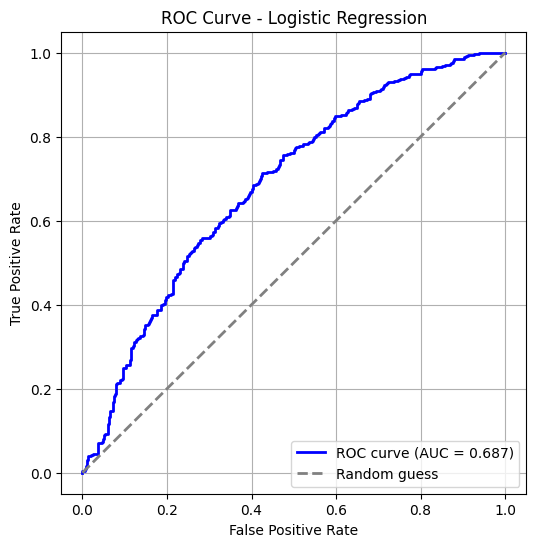

In [18]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for the positive class
y_prob = logreg.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Discussion

The logistic regression model developed in this project provides a baseline estimate of the probability of successfully converting a fourth-down attempt given game-state information. Evaluation on the 2025 test set yielded an ROC-AUC of 0.6865 and a Brier score of 0.2184, indicating that while the model captures meaningful signal from features such as yards-to-go, field position, and play type, its overall predictive performance is moderate.

### Practical Use and Limitations

Given these results, the logistic regression model cannot be used as a standalone decision-making tool. Its moderate discrimination and calibration imply that it may misestimate conversion probabilities in a nontrivial number of cases, which could lead to suboptimal fourth-down decisions if relied upon directly. As such, deploying this model in isolation would be risky.

Importantly, more complex models, including a Random Forest and a neural network, did not meaningfully improve performance over logistic regression. This suggests that the predictive signal available in the current feature set is largely linear and that increased model complexity alone is insufficient to yield better probability estimates. Nonetheless, the project demonstrates that probability-based modeling of fourth-down conversions is feasible, and that a well-trained model could serve as a useful component within a larger decision-support system, where predictions are combined with additional contextual information such as score differential, game situation, and strategic preferences.

### Risks of using the baseline model:

Misclassification of conversion attempts, leading to unfavorable field position or missed scoring opportunities

Overreliance on a simple linear model that cannot capture nonlinear relationships or situational nuances

### Potential benefits of a better model:

Providing interpretable probability estimates that support informed fourth-down decision-making

Enabling integration into a broader decision-support system alongside contextual factors such as score differential and game situation

Offering a consistent framework for evaluating risk across different game scenarios

### Future improvements include:

While more complex models such as Random Forests and neural networks did not improve performance with the current feature set, future gains are likely to come from richer contextual information rather than increased model complexity. Potential improvements include incorporating score differential, time remaining, game quarter, weather conditions, and dynamic team performance metrics. With these enhancements, a probabilistic model could become a valuable component within a larger system designed to support real-time fourth-down decisions.

### Summary

In conclusion, while the logistic regression model is not suitable for direct deployment on its own, the approach establishes a strong foundation for fourth-down probability estimation. Future improvements are more likely to come from richer contextual features rather than increased model complexity, and could result in a model that meaningfully supports real-world fourth-down decision-making.